In [24]:
import json
import os

import numpy as np
import pandas as pd

dir = '../large_files/new_beam_matching_experiment_1nrec'
#dir = '../data/results/experiments/new_beam_matching_experiment_15'

data_df = pd.read_csv(os.path.join(dir, 'data.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

data_df['n_best_pcis'] = data_df['n_best_pcis'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')
data_df['n_best_beams'] = data_df['n_best_beams'].apply(lambda x: 'all' if np.isnan(x) else f'{int(x)}')


#data_df['runtime'] = data_df['runtime'] * 1000 / 2500


def get_strat(row):
    if row['n_best_pcis'] == 'all' and row['n_best_beams'] == 'all':
        return 'All PCIs and all beams'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == 'all':
        return 'Only best PCI and all beams'
    elif row['n_best_pcis'] == 'all' and row['n_best_beams'] == '1':
        return 'All PCIs and only best beam'
    elif row['n_best_pcis'] == '1' and row['n_best_beams'] == '1':
        return 'Only best PCI and only best beam'
    return 'unknown strategy'


data_df['config'] = data_df.apply(get_strat, axis=1)

data_df


,errors,complexity,run,n_best_pcis,n_best_beams,config
0,2.221874,3373656.0,0.0,all,all,All PCIs and all beams
1,3.023250,3373656.0,0.0,all,all,All PCIs and all beams
2,0.274133,3373656.0,0.0,all,all,All PCIs and all beams
3,9.892799,3373656.0,0.0,all,all,All PCIs and all beams
4,6.301775,3373656.0,0.0,all,all,All PCIs and all beams
...,...,...,...,...,...,...
5843987,6.713752,2820978.0,14.0,19,8,unknown strategy
5843988,3.406828,2820978.0,14.0,19,8,unknown strategy
5843989,16.666779,2820978.0,14.0,19,8,unknown strategy
5843990,0.802257,2820978.0,14.0,19,8,unknown strategy


In [2]:


entries = [str(i) for i in range(5, 30)]
data = data_df[data_df['n_best_pcis'].isin(entries)]

data['n_best_pcis'] = data['n_best_pcis'].apply(lambda x: int(x))
#data = data[data['n_best_beams'] == '1']

comps = data.groupby(['n_best_beams'])['complexity'].mean().values


def calculate_percentage_increase(numbers):
    percentage_increases = []
    for i in range(1, len(numbers)):
        previous_number = numbers[i - 1]
        current_number = numbers[i]
        if previous_number != 0:
            increase = ((current_number - previous_number) / previous_number) * 100
        else:
            increase = float('inf')  # Handle division by zero if needed
        percentage_increases.append(increase)
    return percentage_increases


comps = [int(c) for c in comps]

print(comps)

percs = calculate_percentage_increase(comps)
print(percs[1:])
print(np.array(percs[1:]).mean())

[]
[]
nan


/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_12564/2276288724.py:29: RuntimeWarning: Mean of empty slice.
  print(np.array(percs[1:]).mean())
/Users/andreres/Documents/UIO/master/thesis/dev/5G_localization/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
# Calculate the mean of 'errors' for each 'config'


#data = data_df[data_df['operator'].isin([10])]
data = data_df
res = data.groupby('config')['complexity'].median()

# Extract specific configurations
ap_ab = res['All PCIs and all beams']  # Most comprehensive
ap_bb = res['All PCIs and only best beam']
bp_ab = res['Only best PCI and all beams']
bp_bb = res['Only best PCI and only best beam']  # Least comprehensive

print(f'ap_ab {ap_ab}')  # most comprehensive
print(f'ap_bb {ap_bb}')
print(f'bp_ab {bp_ab}')
print(f'bp_bb {bp_bb}')  # least comprehensive

# Calculate the percentage increase
(ap_bb - ap_ab) / ap_ab * 100

ap_ab 929576.5
ap_bb 885434.0
bp_ab 328890.0
bp_bb 186561.5


np.float64(-4.748667807329467)

In [4]:
res = []
for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams']):
    errors = data.groupby('run')['errors'].mean().values
    complexity = data.groupby('run')['complexity'].mean().values
    print(group)
    for i in range(errors.shape[0]):
        res.append((group[0], group[1], errors[i], complexity[i]))

order = [str(x) for x in range(1, 20)] + ['all']

df = pd.DataFrame(res,
                  columns=['n_best_pcis', 'n_best_beams', 'errors', 'complexity'])
df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)

df[df['n_best_pcis'] == 'all']['errors'].mean()

# res = []
# for group, data in data_df.groupby(['n_best_pcis', 'n_best_beams', 'operator', 'config']):
#     errors = data.groupby('run')['errors'].mean().values
#     complexity = data.groupby('run')['complexity'].mean().values
#     runtime = data.groupby('run')['runtime'].mean().values
#
#     for i in range(errors.shape[0]):
#         res.append((group[0], group[1], group[2], errors[i], complexity[i], group[3], runtime[i]))
#
# order = [str(x) for x in range(1, 20)] + ['all']
#
# df = pd.DataFrame(res,
#                   columns=['n_best_pcis', 'n_best_beams', 'operator', 'errors', 'complexity', 'config', 'runtime'])
# df['n_best_pcis'] = pd.Categorical(df['n_best_pcis'], categories=order, ordered=True)
# df.sort_values(by=['n_best_pcis', 'n_best_beams'], inplace=True)
#
# df[df['n_best_pcis'] == 'all']['errors'].mean()
#
# df.groupby(['operator', 'config'])['errors'].mean()

('1', '1')
('1', 'all')
('all', '1')
('all', 'all')


np.float64(12.892384066744437)

In [5]:
one = df[df['n_best_pcis'] == '1']['errors'].mean()
two = df[df['n_best_pcis'] == '2']['errors'].mean()

print(f'one: {one} to two: {two}')

print(f'Decrease in error from one to two pcis, {int((one - two) / one * 100)} %')

one: 60.734985484137965 to two: nan


ValueError: cannot convert float NaN to integer

In [6]:
print(f"2-3 beam improvement for low PCI scenarios")

data = df[df['n_best_pcis'].isin([str(i) for i in range(1, 5)])]

ones = data[data['n_best_beams'] == '1']['errors'].mean()
twos = data[data['n_best_beams'] == '2']['errors'].mean()
fives = data[data['n_best_beams'] == '5']['errors'].mean()

print(f'Error decrease from one to two best beams is {(ones - twos) / ones * 100} %')

print(f'Error increase from two to five best beams is {(twos - fives) / twos * 100} %')

print('Beam 1-2 improvement in all PCI scenarios:')

ones = df[df['n_best_beams'] == '1']['errors'].mean()
twos = df[df['n_best_beams'] == '2']['errors'].mean()
print(f'Error decrease from one to two best beams is {(ones - twos) / ones * 100} %')

2-3 beam improvement for low PCI scenarios
Error decrease from one to two best beams is nan %
Error increase from two to five best beams is nan %
Beam 1-2 improvement in all PCI scenarios:
Error decrease from one to two best beams is nan %


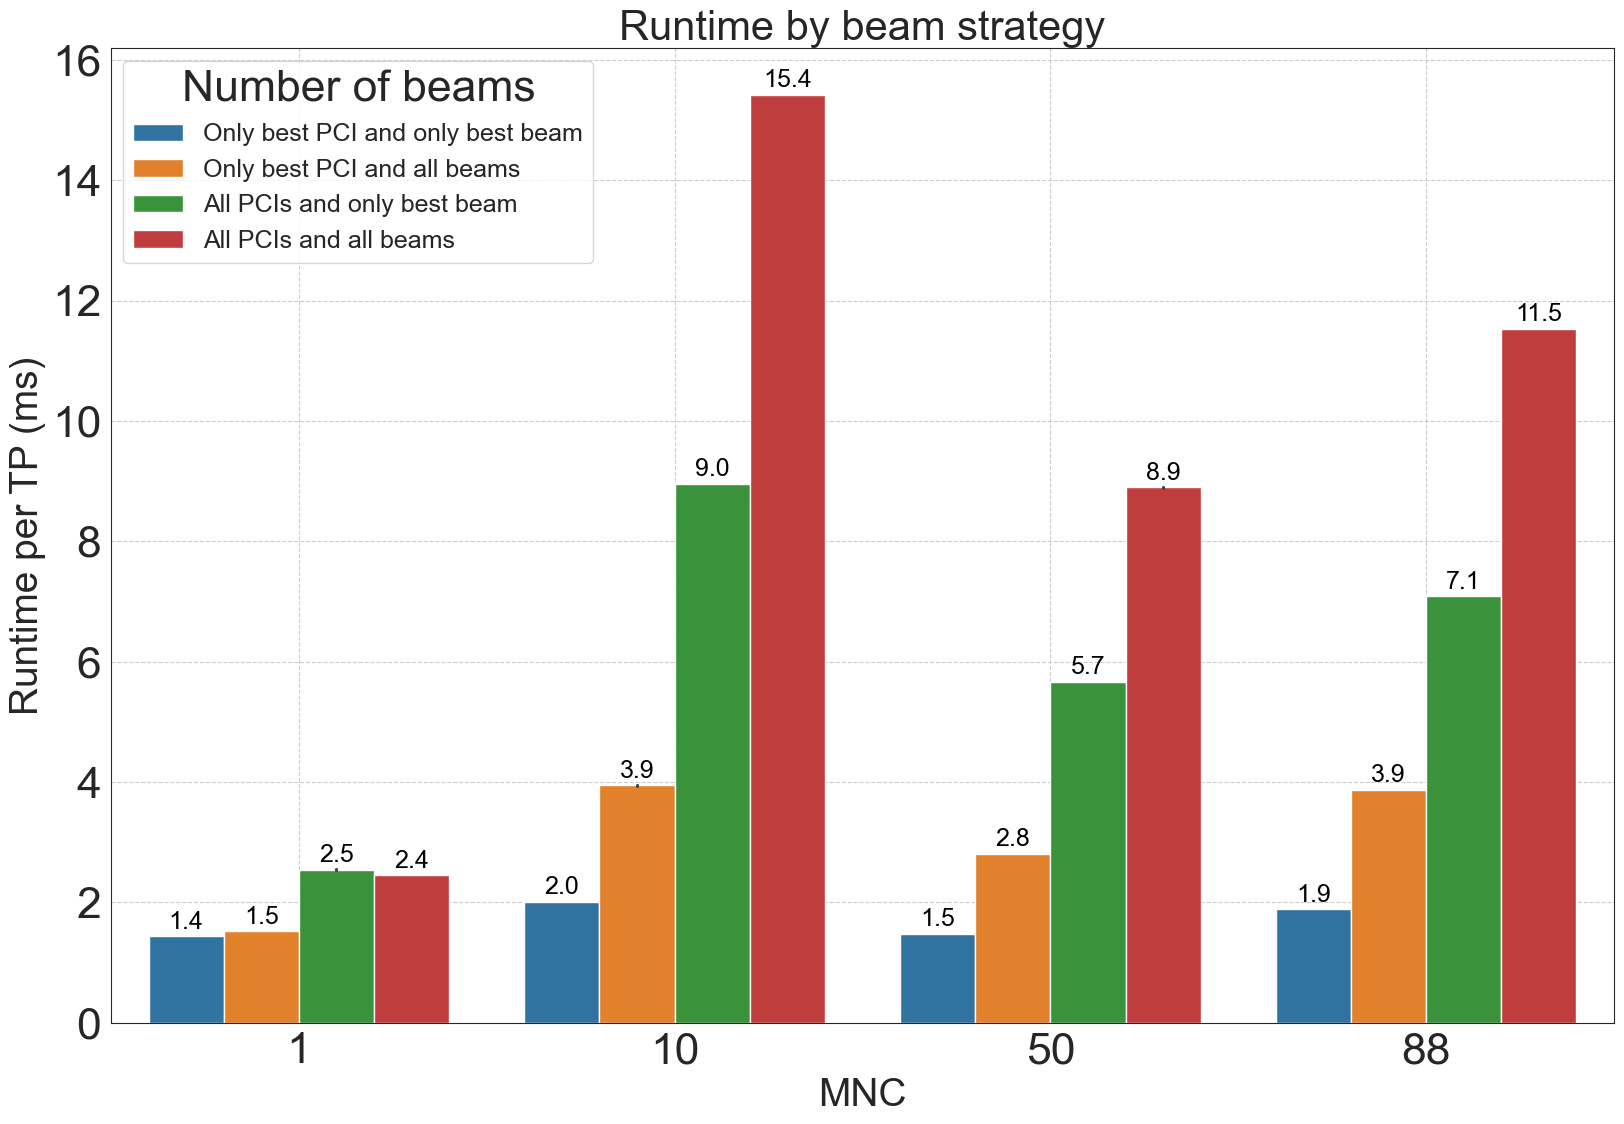

config
All PCIs and all beams              9.574118
All PCIs and only best beam         6.065210
Only best PCI and all beams         3.036671
Only best PCI and only best beam    1.703250
Name: runtime, dtype: float64

In [19]:
import pandas as pd
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 32})


def plot_operator(
        df: pd.DataFrame,
        y: str,
        x_label: str,
        y_label: str,
        title: str,
):
    hue_order = [
        'Only best PCI and only best beam',
        'Only best PCI and all beams',
        'All PCIs and only best beam',
        'All PCIs and all beams',
    ]

    plt.figure(figsize=(17, 12))

    sns.set_style("white")

    box = False
    if box:
        bar_plot = sns.boxplot(
            data=df,
            x='operator',
            y=y,
            hue='config',
            hue_order=hue_order,
            showfliers=False,
        )


    else:
        bar_plot = sns.barplot(
            data=df,
            x='operator',
            y=y,
            hue='config',
            hue_order=hue_order,
        )
        # Annotate each bar with values in 'k' format
        for p in bar_plot.patches:
            height = p.get_height()
            if height != 0:  # Check if the height is not zero
                bar_plot.annotate(f'{height:,.1f}',  # Changed to use 'k' format
                                  (p.get_x() + p.get_width() / 2., height),
                                  ha='center', va='center',
                                  fontsize=18, color='black', xytext=(0, 10),
                                  textcoords='offset points')

    # Format y-axis in thousands
    #formatter = FuncFormatter(lambda x, _: f'{x / 1000:,.0f}k')
    #plt.gca().yaxis.set_major_formatter(formatter)  # Uncommented this line

    # Add labels and title
    plt.xlabel(x_label, fontsize=28)
    plt.ylabel(y_label, fontsize=28)
    plt.title(title, fontsize=30)

    plt.legend(title='Number of beams', loc='upper left', fontsize=18)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot_operator(data_df, 'errors', 'MNC', 'Error (m)', 'Distribution of error by beam strategy')
#plot_operator(data_df, 'complexity', 'MNC', 'Complexity', 'Complexity by beam strategy')
plot_operator(data_df, 'runtime', 'MNC', 'Runtime per TP (ms)', 'Runtime by beam strategy')

data_df.groupby('config')['runtime'].mean()


In [22]:
means = data_df.groupby('config')['runtime'].mean()

all = means['All PCIs and all beams']
allmost = means['All PCIs and only best beam']

(all - allmost) / all * 100

np.float64(36.64993485840203)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # baseline = df[df['n_best_pcis'] == 'all']['errors'].mean()
    #
    # data = df[df['n_best_pcis'] != 'all']

    plt.figure(figsize=(17, 12))
    sns.set_style("white")
    sns.boxplot(
        data=df,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
    )
    # Add labels and title
    plt.xlabel('N best PCIs')
    plt.ylabel('Error (m)')
    plt.title('Error by operator and PCA')

    plt.legend(title='Number of beams', loc='upper right', fontsize=22, ncol=2, title_fontsize=22)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


#plot(df[df['n_best_pcis'] == 9])

highs = [str(i) for i in range(10, 20)] + ['all']
lows = [str(i) for i in range(2, 5)]


#plot(data_df[data_df['n_best_pcis'].isin(highs)])
#plot(data_df[data_df['n_best_pcis'].isin(lows)])

def do_plot(df):
    df_lows = df[df['n_best_pcis'].isin(lows)]
    df_lows['n_best_pcis'] = pd.Categorical(df_lows['n_best_pcis'], categories=lows, ordered=True)

    df_highs = df[df['n_best_pcis'].isin(highs)]
    df_highs['n_best_pcis'] = pd.Categorical(df_highs['n_best_pcis'], categories=highs, ordered=True)

    # plot the points
    plot(df)
    plot(df_lows)
    # plot(df_highs)


df['n_best_beams'] = df['n_best_beams'].apply(lambda x: x if x != 'all' else '8')

do_plot(df)

In [ ]:
def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # Create the main figure and axes
    fig, ax = plt.subplots(figsize=(17, 12))
    sns.set_style("white")

    mask_all = df['n_best_pcis'] == 'all'
    df_all = df[mask_all]
    df_rest = df[~mask_all]

    baseline = df_all['errors'].mean()

    # Create the main boxplot with only non-'all' data
    sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
        ax=ax
    )

    # Add the baseline as a horizontal blue dashed line
    baseline_line = ax.axhline(y=baseline, color='blue', linestyle='--', linewidth=3)

    # Add labels and title
    ax.set_xlabel('N best PCIs')
    ax.set_ylabel('Error (m)')
    ax.set_title('Error by number of best PCA and Beams')

    # Explicitly set the x-tick labels to exclude 'all'
    current_xticks = ax.get_xticks()
    current_xticklabels = [label.get_text() for label in ax.get_xticklabels()]

    # Filter out 'all' if it exists in the labels
    filtered_xticks = []
    filtered_xticklabels = []
    for i, label in enumerate(current_xticklabels):
        if label != 'all':
            filtered_xticks.append(current_xticks[i])
            filtered_xticklabels.append(label)

    ax.set_xticks(filtered_xticks)
    ax.set_xticklabels(filtered_xticklabels)

    # Add legend to the main plot, including the baseline line
    handles, labels = ax.get_legend_handles_labels()
    handles.append(baseline_line)
    labels.append('Baseline')
    ax.legend(handles=handles, labels=labels, title='Number of beams',
              loc='upper left', fontsize=22, ncol=3, title_fontsize=22, bbox_to_anchor=(0.05, 1.0),
              # x=0.15 moves right, y=1.0 positions at top
              )

    ax.grid(linestyle='--')

    # Create an inset axes for the zoomed region
    axins = fig.add_axes([0.6, 0.52, 0.35, 0.35])

    # Create the same boxplot in the inset, but it will be zoomed
    axi = sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='errors',
        hue='n_best_beams',
        showfliers=False,
        ax=axins
    )

    # No baseline line in the small plot as requested

    axi.set_ylabel('')
    axi.grid(linestyle='--')

    # Set the x-limits to focus on n_best_pcis from 2-4
    all_categories = df_rest['n_best_pcis'].unique()

    # Find indices of categories '2', '3', and '4'
    try:
        idx_2 = list(all_categories).index('2')
        idx_3 = list(all_categories).index('3')
        idx_4 = list(all_categories).index('4')
        axins.set_xlim(idx_2 - 0.5, idx_4 + 0.5)
    except (ValueError, TypeError):
        # If categories are numeric, not strings
        axins.set_xlim(1.5, 4.5)

    # Adjust y-limits for the zoomed area
    subset = df_rest[df_rest['n_best_pcis'].isin(['2', '3', '4'])]
    y_min = subset['errors'].min() * 0.95
    y_max = subset['errors'].max() * 1.05
    axins.set_ylim(y_min, y_max)
    axins.tick_params(axis='both', which='major', labelsize=32)
    for spine in axins.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)

    # Remove legend from inset to avoid clutter
    axins.get_legend().remove()

    # Mark the zoomed region in the main plot
    from matplotlib.patches import Rectangle

    # Get the position of the categories in the main plot
    try:
        x_min = idx_2 - 0.5
        x_max = idx_4 + 0.5
    except (ValueError, TypeError, NameError):
        x_min = 1.5
        x_max = 4.5

    # Get the full y-range of the main plot
    main_y_min, main_y_max = ax.get_ylim()

    rect_y_min = main_y_min
    rect_height = (main_y_max - main_y_min) * 0.3

    rect = Rectangle((x_min, rect_y_min + 9), x_max - x_min, rect_height,
                     fill=False, edgecolor='red', linestyle='--', linewidth=2)
    ax.add_patch(rect)

    # Update the title for the inset
    axins.set_title('Zoom: 2 - 4 best PCIs', fontsize=24)

    # Adjust labels on inset
    axins.set_xlabel('')
    axins.tick_params(axis='both', which='major', labelsize=20)

    plt.tight_layout()
    plt.show()


plot(df)


ValueError: Axis limits cannot be NaN or Inf

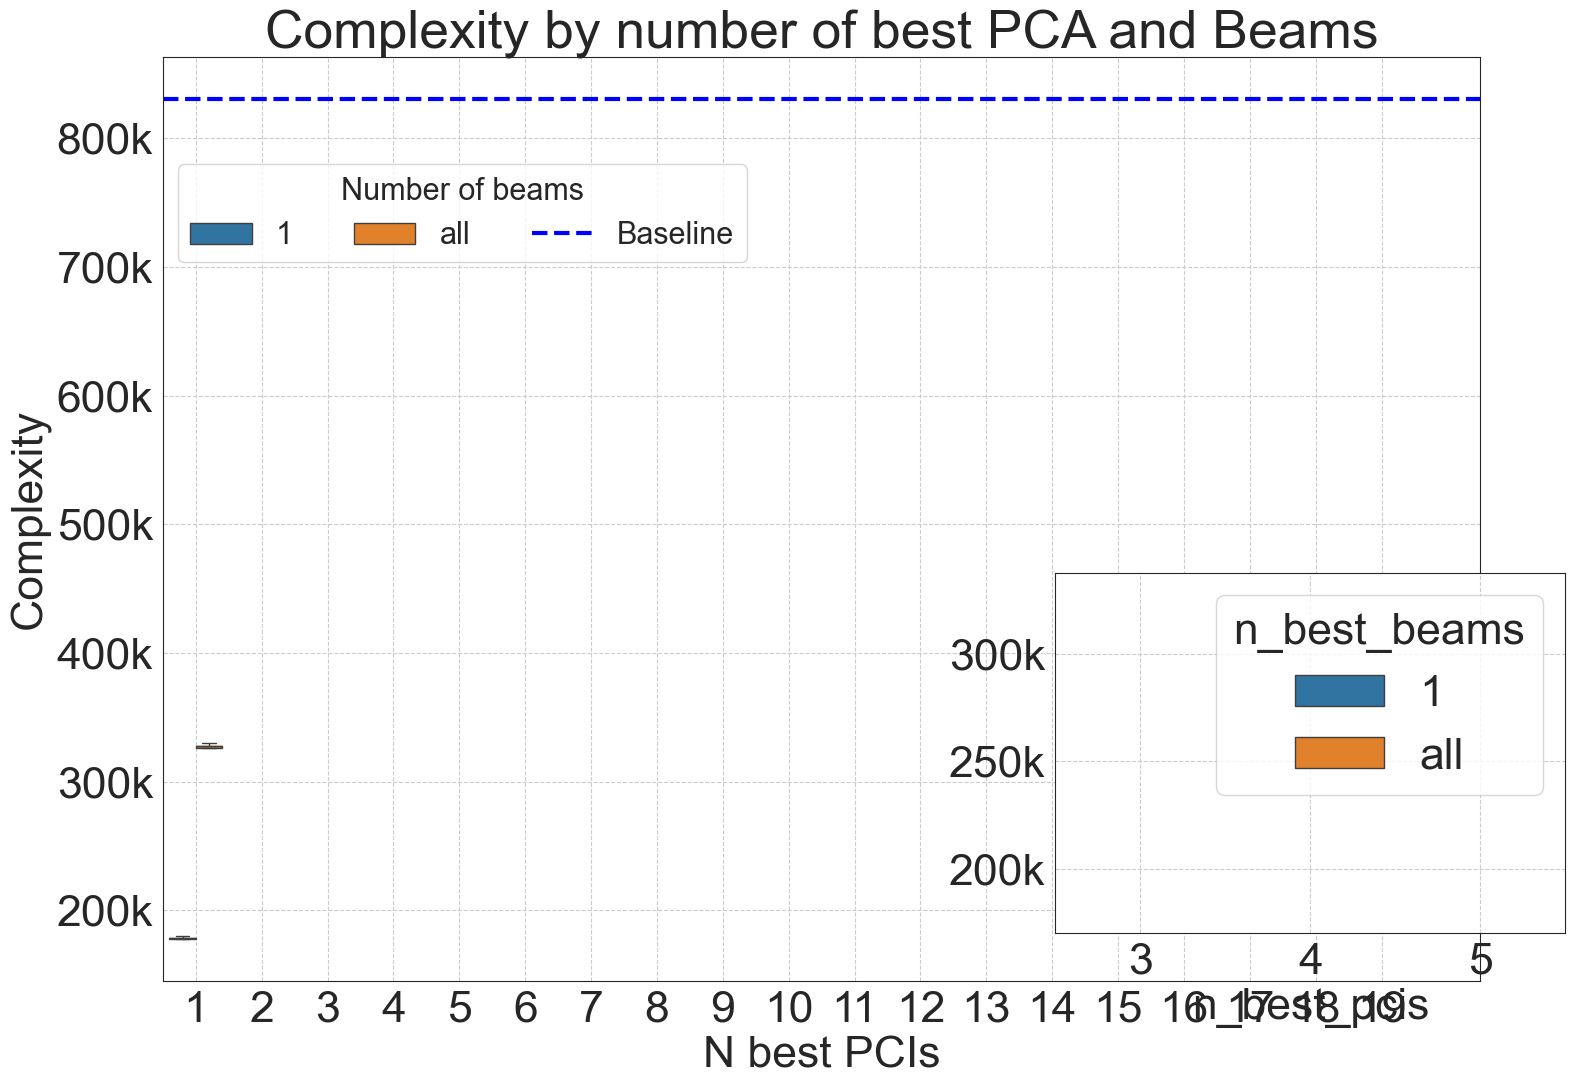

In [23]:
def plot(df: pd.DataFrame):
    plt.rcParams.update({"font.size": 32})

    # Create the main figure and axes
    fig, ax = plt.subplots(figsize=(17, 12))
    sns.set_style("white")

    mask_all = df['n_best_pcis'] == 'all'
    df_all = df[mask_all]
    df_rest = df[~mask_all]

    baseline = df_all['complexity'].mean()

    # Create the main boxplot with only non-'all' data
    sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
        ax=ax
    )

    # Add the baseline as a horizontal blue dashed line
    baseline_line = ax.axhline(y=baseline, color='blue', linestyle='--', linewidth=3)

    # Add labels and title
    ax.set_xlabel('N best PCIs')
    ax.set_ylabel('Complexity')
    ax.set_title('Complexity by number of best PCA and Beams')

    # Explicitly set the x-tick labels to exclude 'all'
    current_xticks = ax.get_xticks()
    current_xticklabels = [label.get_text() for label in ax.get_xticklabels()]

    # Filter out 'all' if it exists in the labels
    filtered_xticks = []
    filtered_xticklabels = []
    for i, label in enumerate(current_xticklabels):
        if label != 'all':
            filtered_xticks.append(current_xticks[i])
            filtered_xticklabels.append(label)

    ax.set_xticks(filtered_xticks)
    ax.set_xticklabels(filtered_xticklabels)

    def thousands_formatter(x, pos):
        return f'{x / 1000:,.0f}k' if x >= 1000 else f'{x:,.0f}'

    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Add legend to the main plot, including the baseline line
    handles, labels = ax.get_legend_handles_labels()
    handles.append(baseline_line)
    labels.append('Baseline')
    ax.legend(handles=handles, labels=labels, title='Number of beams',
              loc='upper left', fontsize=22, ncol=3, title_fontsize=22, bbox_to_anchor=(0.0, 0.9),
              # x=0.15 moves right, y=1.0 positions at top
              )

    ax.grid(linestyle='--')

    # Create an inset axes for the zoomed region
    axins = fig.add_axes([0.65, 0.15, 0.3, 0.3])

    # Create the same boxplot in the inset, but it will be zoomed
    axi = sns.boxplot(
        data=df_rest,
        x='n_best_pcis',
        y='complexity',
        hue='n_best_beams',
        showfliers=False,
        ax=axins
    )

    # No baseline line in the small plot as requested
    axi.set_ylabel('')
    axi.grid(linestyle='--')
    axi.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))

    # Set the x-limits to focus on n_best_pcis from 2-4
    all_categories = df_rest['n_best_pcis'].unique()

    # Find indices of categories '2', '3', and '4'
    try:
        idx_2 = list(all_categories).index('3')
        idx_3 = list(all_categories).index('4')
        idx_4 = list(all_categories).index('5')
        axins.set_xlim(idx_2 - 0.5, idx_4 + 0.5)
    except (ValueError, TypeError):
        # If categories are numeric, not strings
        axins.set_xlim(1.5, 4.5)

    # Adjust y-limits for the zoomed area
    subset = df_rest[df_rest['n_best_pcis'].isin(['2', '3', '4'])]
    y_min = subset['complexity'].min() * 0.95
    y_max = subset['complexity'].max() * 1.05
    axins.set_ylim(y_min, y_max)
    axins.tick_params(axis='both', which='major', labelsize=32)

    for spine in axins.spines.values():
        spine.set_edgecolor('red')
        spine.set_linewidth(2)

    # Remove legend from inset to avoid clutter
    axins.get_legend().remove()

    # Mark the zoomed region in the main plot
    from matplotlib.patches import Rectangle

    # Get the position of the categories in the main plot
    try:
        x_min = idx_2 - 0.5
        x_max = idx_4 + 0.5
    except (ValueError, TypeError, NameError):
        x_min = 1.5
        x_max = 4.5

    # Get the full y-range of the main plot
    main_y_min, main_y_max = ax.get_ylim()

    rect_y_min = main_y_min
    rect_height = (main_y_max - main_y_min) * 0.45

    rect = Rectangle((x_min, 500000), x_max - x_min, rect_height,
                     fill=False, edgecolor='red', linestyle='--', linewidth=2)
    ax.add_patch(rect)

    # Update the title for the inset
    axins.set_title('Zoom: 2 - 4 best PCIs', fontsize=24)

    # Adjust labels on inset
    axins.set_xlabel('')
    axins.tick_params(axis='both', which='major', labelsize=20)

    plt.tight_layout()
    plt.show()


plot(df)


In [ ]:
data_df.groupby(['operator', 'config', 'run'])['runtime'].count()